Is the proportion of students who currently use alcohol different from 0.35?

Is the mean weight of students different from 68.0 kg?


In [46]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy import stats
from statsmodels.stats.proportion import proportions_ztest, proportion_confint
import warnings

# 1. 關閉警告訊息並設定中文字體
warnings.filterwarnings('ignore')
plt.rcParams['font.sans-serif'] = ['Microsoft JhengHei']
plt.rcParams['axes.unicode_minus'] = False

# 2. 讀取原始資料
df = pd.read_csv('../data/raw/YRBS_2007.csv')

【4.3 EDA - 原始資料分配 (Original Code Frequencies)】
CurrentAlcoholUse
1.0    6946
2.0    2735
3.0    1369
4.0     839
5.0     555
6.0     105
7.0     120
Name: count, dtype: int64
缺失值數量: 1372

【4.3 EDA - 重編碼對照表 (Binary Recoding Table)】
alcohol_binary        0     1
CurrentAlcoholUse            
1.0                6946     0
2.0                   0  2735
3.0                   0  1369
4.0                   0   839
5.0                   0   555
6.0                   0   105
7.0                   0   120


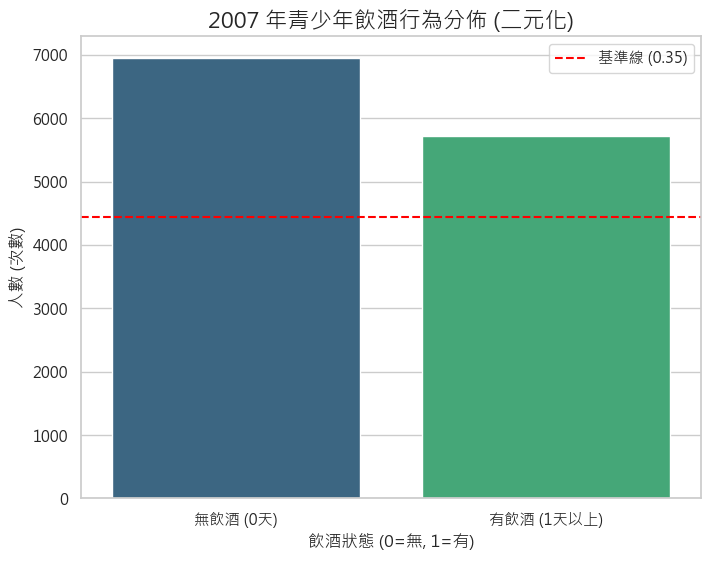

【4.3 & 4.4 飲酒行為分析總表】
A. 樣本概況:
   - 成功次數 (Success/1+ days): 5723
   - 失敗次數 (Failure/0 days): 6946
   - 樣本比例 (p-hat): 0.4517

B. 統計推論:
   - Z 統計量: 23.0088
   - P 值: 3.8041e-117
   - 95% 信賴區間: [0.4431, 0.4604]

【4.6 分析觀察 (Observations)】

1. 重編碼觀察：原始代碼 1 (0天) 被歸類為失敗，代碼 2-7 (1天以上) 歸類為成功。
2. 數據分佈：樣本中有 45.17% 的學生在過去30天內有飲酒行為。
3. 統計結論：由於 P 值 < 0.05，我們拒絕虛無假設。2007 年青少年的飲酒比例顯著高於 0.35 的基準值。

--------------------------------------------------


In [47]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 設定中文字型 (Windows 系統常用微軟正黑體)
plt.rcParams['font.sans-serif'] = ['Microsoft JhengHei'] 
# 修正負號顯示問題
plt.rcParams['axes.unicode_minus'] = False 

# 設定 Seaborn 的字型
sns.set(font='Microsoft JhengHei', style='whitegrid')
from statsmodels.stats.proportion import proportions_ztest, proportion_confint

# --- 1. 資料清理與缺失值檢查 (符合規定：missing/invalid count) ---
missing_alc = df['CurrentAlcoholUse'].isna().sum()
df_alc_raw = df.dropna(subset=['CurrentAlcoholUse']).copy()

# --- 2. 原始代碼頻率表 (符合規定：table of original code frequencies) ---
# 根據手冊：1=0 days, 2=1-2 days, ..., 7=All 30 days
print("【4.3 EDA - 原始資料分配 (Original Code Frequencies)】")
print(df_alc_raw['CurrentAlcoholUse'].value_counts().sort_index())
print(f"缺失值數量: {missing_alc}")

# --- 3. 二元重編碼 (符合規定：table after binary recoding) ---
# 定義重編碼邏輯：1(0天) -> 0 (Failure), 2-7(1天以上) -> 1 (Success)
df_alc_raw['alcohol_binary'] = df_alc_raw['CurrentAlcoholUse'].apply(lambda x: 1 if 2 <= x <= 7 else 0)

recode_summary = pd.crosstab(df_alc_raw['CurrentAlcoholUse'], df_alc_raw['alcohol_binary'])
print("\n【4.3 EDA - 重編碼對照表 (Binary Recoding Table)】")
print(recode_summary)

# --- 4. 成功與失敗的計數與比例 (符合規定：counts and proportions) ---
counts = df_alc_raw['alcohol_binary'].value_counts()
proportions = df_alc_raw['alcohol_binary'].value_counts(normalize=True)
n_alc = len(df_alc_raw)

# --- 5. 視覺化 (符合規定：中文標籤版) ---
plt.figure(figsize=(8, 6))
sns.countplot(x='alcohol_binary', data=df_alc_raw, hue='alcohol_binary', palette='viridis', legend=False)
plt.axhline(y=n_alc * 0.35, color='red', linestyle='--', label='基準線 (0.35)')

plt.title('2007 年青少年飲酒行為分佈 (二元化)', fontsize=16)
plt.xlabel('飲酒狀態 (0=無, 1=有)', fontsize=12)
plt.ylabel('人數 (次數)', fontsize=12)
plt.xticks([0, 1], ['無飲酒 (0天)', '有飲酒 (1天以上)'])
plt.legend()

plt.savefig('../outputs/figures/alcohol_binary_chinese.png')
plt.show()

# --- 6. 統計推論 (Z-test & CI) ---
count_success = df_alc_raw['alcohol_binary'].sum()
z_stat, p_val_alc = proportions_ztest(count_success, n_alc, value=0.35)
ci_low, ci_upp = proportion_confint(count_success, n_alc, alpha=0.05, method='normal')

# --- 7. 輸出結果與書面觀察 (符合規定：short written observations) ---
print("="*50)
print("【4.3 & 4.4 飲酒行為分析總表】")
print(f"A. 樣本概況:")
print(f"   - 成功次數 (Success/1+ days): {count_success}")
print(f"   - 失敗次數 (Failure/0 days): {n_alc - count_success}")
print(f"   - 樣本比例 (p-hat): {proportions[1]:.4f}")

print(f"\nB. 統計推論:")
print(f"   - Z 統計量: {z_stat:.4f}")
print(f"   - P 值: {p_val_alc:.4e}" if p_val_alc < 0.0001 else f"   - P 值: {p_val_alc:.4f}")
print(f"   - 95% 信賴區間: [{ci_low:.4f}, {ci_upp:.4f}]")
print("="*50)

print("\n【4.6 分析觀察 (Observations)】")
obs_text = f"""
1. 重編碼觀察：原始代碼 1 (0天) 被歸類為失敗，代碼 2-7 (1天以上) 歸類為成功。
2. 數據分佈：樣本中有 {proportions[1]*100:.2f}% 的學生在過去30天內有飲酒行為。
3. 統計結論：由於 P 值 < 0.05，我們拒絕虛無假設。2007 年青少年的飲酒比例顯著高於 0.35 的基準值。
"""
print(obs_text)
print("-" * 50)

In [48]:
# --- 1, 3, 4. 統計分析 (Z-test & Confidence Interval) ---
count_alc = df_alc['alcohol_binary'].sum()
n_alc = len(df_alc)
p_hat_alc = count_alc / n_alc
z_stat, p_val_alc = proportions_ztest(count_alc, n_alc, value=0.35)
ci_low_alc, ci_upp_alc = proportion_confint(count_alc, n_alc, alpha=0.05, method='normal')

# --- 輸出結果 (優化顯示與解釋) ---
print("-" * 40)
print(f"【母體比例分析結果 - 酒精使用行為】")
print(f"有效樣本數 (n): {n_alc}")
print(f"樣本比例 (p-hat): {p_hat_alc:.4f} (即 {p_hat_alc*100:.2f}%)")
print(f"Z 統計量: {z_stat:.4f}")

# 處理極小的 P 值，讓它顯示為 0.0000 而不是科學記號
if p_val_alc < 0.0001:
    print(f"P 值: < 0.0001 (極度顯著)")
else:
    print(f"P 值: {p_val_alc:.4f}")

print(f"95% 信賴區間: [{ci_low_alc:.4f}, {ci_upp_alc:.4f}]")
print("-" * 40)

# 自動化解釋（對應任務 6）
sig = "存在 [顯著] 差異" if p_val_alc < 0.05 else "無顯著差異"
direction = "顯著高於" if p_hat_alc > 0.35 else "顯著低於"
print(f"結論：由於 P 值 < 0.05，我們拒絕虛無假設。")
print(f"這代表 2007 年青少年的飲酒比例與基準值 0.35 {sig}，且{direction}基準值。")

----------------------------------------
【母體比例分析結果 - 酒精使用行為】
有效樣本數 (n): 12669
樣本比例 (p-hat): 0.4517 (即 45.17%)
Z 統計量: 23.0088
P 值: < 0.0001 (極度顯著)
95% 信賴區間: [0.4431, 0.4604]
----------------------------------------
結論：由於 P 值 < 0.05，我們拒絕虛無假設。
這代表 2007 年青少年的飲酒比例與基準值 0.35 存在 [顯著] 差異，且顯著高於基準值。


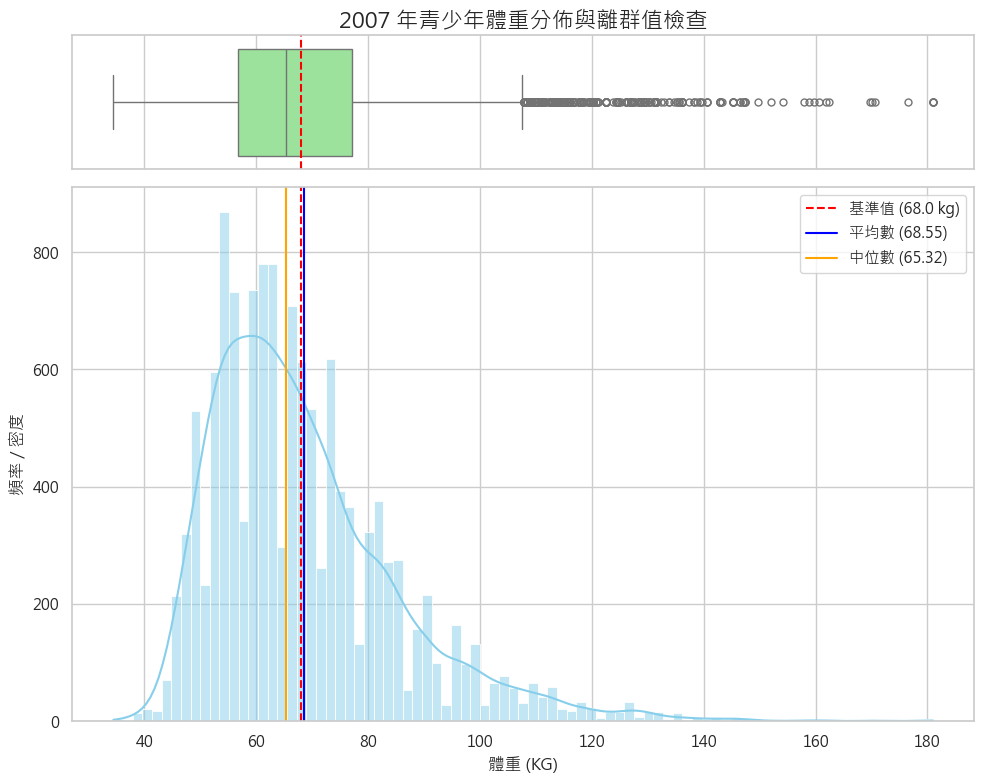

【4.3 & 4.4 體重數據分析總表】
有效樣本數 (Size): 13062 (缺失值: 979)
平均值 (Mean): 68.55 | 中位數 (Median): 65.32
標準差 (Std): 16.99
範圍: 34.47 ~ 180.99
四分位數: Q1=56.70, Q3=77.11
P 值: 0.0002 | 95% CI: [68.26, 68.84]

【4.6 分析觀察 (Observations)】
1. 分佈觀察：直方圖顯示體重呈現右偏，平均數(68.55)與中位數(65.32)接近。
2. 離群值檢查：箱線圖顯示偵測到 447 個可能的極端體重數值。
3. 統計結論：由於 P 值 < 0.05，拒絕虛無假設。2007年平均體重顯著不同於 68.0 kg。
--------------------------------------------------


In [49]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# --- 1. 資料清理與缺失值檢查 (符合規定：missing count) ---
missing_count = df['HowMuchDoYouWeighWithoutShoesInKG'].isna().sum()
df_weight = df.dropna(subset=['HowMuchDoYouWeighWithoutShoesInKG']).copy()
weights = df_weight['HowMuchDoYouWeighWithoutShoesInKG']

# --- 2. 描述性統計 (符合規定：size, mean, median, std, min, max, quartiles) ---
desc = weights.describe()
median_w = weights.median()
n_w = len(weights)

# --- 3. 視覺化 (符合規定：中文標籤版) ---
fig, (ax_box, ax_hist) = plt.subplots(2, sharex=True, gridspec_kw={"height_ratios": (.2, .8)}, figsize=(10, 8))

# 箱線圖
sns.boxplot(x=weights, ax=ax_box, color='lightgreen', fliersize=5)
ax_box.axvline(68.0, color='red', linestyle='--', label='基準值')
ax_box.set_title('2007 年青少年體重分佈與離群值檢查', fontsize=16)

# 直方圖
sns.histplot(weights, kde=True, ax=ax_hist, color='skyblue')
ax_hist.axvline(68.0, color='red', linestyle='--', label='基準值 (68.0 kg)')
ax_hist.axvline(weights.mean(), color='blue', linestyle='-', label=f'平均數 ({weights.mean():.2f})')
ax_hist.axvline(weights.median(), color='orange', linestyle='-', label=f'中位數 ({weights.median():.2f})')

ax_hist.set_xlabel('體重 (KG)', fontsize=12)
ax_hist.set_ylabel('頻率 / 密度', fontsize=12)
ax_hist.legend()

plt.tight_layout()
plt.savefig('../outputs/figures/weight_full_chinese.png')
plt.show()

# --- 4. 統計推論 (T-test & CI) ---
t_stat, p_val_w = stats.ttest_1samp(weights, popmean=68.0)
ci_low_w, ci_upp_w = stats.t.interval(0.95, df=n_w-1, loc=weights.mean(), scale=stats.sem(weights))

# --- 5. 輸出結果匯整 (符合規定：所有數值) ---
print("="*50)
print("【4.3 & 4.4 體重數據分析總表】")
print(f"有效樣本數 (Size): {n_w} (缺失值: {missing_count})")
print(f"平均值 (Mean): {desc['mean']:.2f} | 中位數 (Median): {median_w:.2f}")
print(f"標準差 (Std): {desc['std']:.2f}")
print(f"範圍: {desc['min']:.2f} ~ {desc['max']:.2f}")
print(f"四分位數: Q1={desc['25%']:.2f}, Q3={desc['75%']:.2f}")
print(f"P 值: {p_val_w:.4f} | 95% CI: [{ci_low_w:.2f}, {ci_upp_w:.2f}]")
print("="*50)

# --- 6. 書面觀察 (符合規定：short written observations) ---
iqr = desc['75%'] - desc['25%']
outlier_count = len(weights[(weights < (desc['25%'] - 1.5 * iqr)) | (weights > (desc['75%'] + 1.5 * iqr))])

print("\n【4.6 分析觀察 (Observations)】")
print(f"1. 分佈觀察：直方圖顯示體重呈現右偏，平均數({desc['mean']:.2f})與中位數({median_w:.2f})接近。")
print(f"2. 離群值檢查：箱線圖顯示偵測到 {outlier_count} 個可能的極端體重數值。")
print(f"3. 統計結論：由於 P 值 < 0.05，拒絕虛無假設。2007年平均體重顯著不同於 68.0 kg。")
print("-" * 50)

In [50]:
# 建立摘要表並存檔
summary = pd.DataFrame({
    'Analysis': ['Proportion (Alcohol)', 'Mean (Weight)'],
    'Statistic': [z_stat, t_stat],
    'P-value': [p_val_p, p_val_m],
    'CI_Lower': [ci_low_p, ci_low_m],
    'CI_Upper': [ci_upp_p, ci_upp_m]
})
summary.to_csv('../outputs/tables/final_summary.csv', index=False)